# Mock Frontier Exploration on a Simple Grid

This notebook demonstrates frontier detection on occupancy grids using Python.

- **Case 1:** One connected frontier region
- **Case 2:** Two separate frontier regions

**Grid encoding**
- `-1` = unknown
- `0` = free
- `1` = occupied

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

UNKNOWN = -1
FREE = 0
OCCUPIED = 1


def find_frontier_cells(grid):
    """Return a boolean mask of frontier cells (free cells adjacent to unknown)."""
    h, w = grid.shape
    frontier = np.zeros_like(grid, dtype=bool)

    for r in range(h):
        for c in range(w):
            if grid[r, c] != FREE:
                continue
            for dr, dc in [(-1, 0), (1, 0), (0, -1), (0, 1)]:
                nr, nc = r + dr, c + dc
                if 0 <= nr < h and 0 <= nc < w and grid[nr, nc] == UNKNOWN:
                    frontier[r, c] = True
                    break
    return frontier


def label_frontier_components(frontier_mask):
    """Label connected frontier components using 4-connectivity."""
    h, w = frontier_mask.shape
    labels = np.zeros((h, w), dtype=int)
    current = 0

    for r in range(h):
        for c in range(w):
            if not frontier_mask[r, c] or labels[r, c] != 0:
                continue

            current += 1
            stack = [(r, c)]
            labels[r, c] = current

            while stack:
                rr, cc = stack.pop()
                for dr, dc in [(-1, 0), (1, 0), (0, -1), (0, 1)]:
                    nr, nc = rr + dr, cc + dc
                    if (
                        0 <= nr < h
                        and 0 <= nc < w
                        and frontier_mask[nr, nc]
                        and labels[nr, nc] == 0
                    ):
                        labels[nr, nc] = current
                        stack.append((nr, nc))

    return labels, current


def show_grid_with_frontiers(grid, title):
    """Plot occupancy grid with cognitive-robotics color semantics."""
    frontier = find_frontier_cells(grid)
    comp_labels, n_components = label_frontier_components(frontier)

    h, w = grid.shape

    # 0 = unexplored (white), 1 = explored (green), 2 = occupied (black), 3 = frontier region (yellow)
    display = np.zeros((h, w), dtype=int)
    display[grid == FREE] = 1
    display[grid == OCCUPIED] = 2
    display[frontier] = 3

    cmap = ListedColormap(["#ffffff", "#2ca02c", "#000000", "#ffd400"])

    fig, ax = plt.subplots(figsize=(6, 6), dpi=150)
    fig.patch.set_facecolor("white")
    fig.patch.set_alpha(1.0)
    ax.set_facecolor("white")
    ax.patch.set_alpha(1.0)

    ax.imshow(display, cmap=cmap, vmin=0, vmax=3, interpolation="nearest")

    fr, fc = np.where(frontier)
    for r, c in zip(fr, fc):
        ax.text(c, r, str(comp_labels[r, c]), ha="center", va="center", color="black", fontsize=8)

    # Full-grid, no padding, and visible cell boundaries.
    ax.set_xlim(-0.5, w - 0.5)
    ax.set_ylim(h - 0.5, -0.5)
    ax.set_xticks(np.arange(-0.5, w, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, h, 1), minor=True)
    ax.grid(which="minor", color="#cfcfcf", linestyle="-", linewidth=0.35)
    ax.tick_params(which="both", left=False, bottom=False, labelleft=False, labelbottom=False)

    # Draw a clear outer border around the full grid image.
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(1.0)
        spine.set_color("black")

    fig.subplots_adjust(left=0, right=1, top=1, bottom=0)
    plt.show()

    print(f"{title} | detected frontier regions: {n_components}")

    return n_components, frontier, comp_labels

## Case 1: One Frontier Region

A single explored free area touches unknown space in one connected boundary.

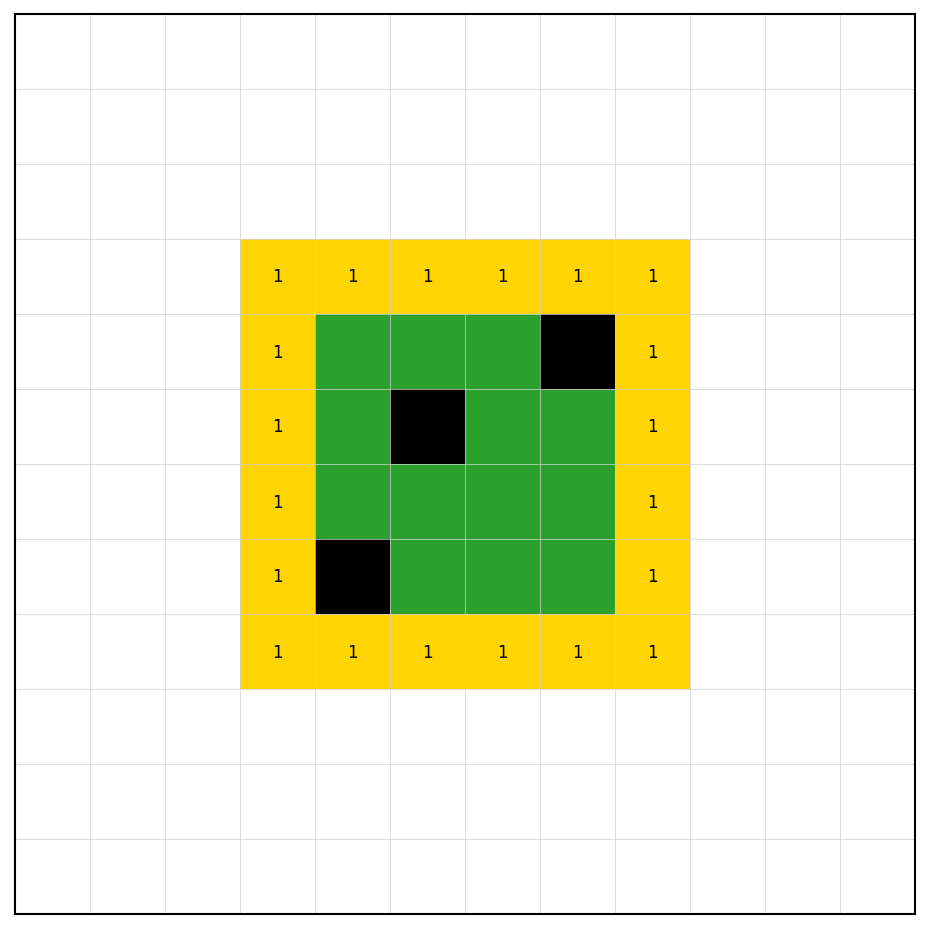

Case 1: One Frontier | detected frontier regions: 1
Case 1 frontier regions: 1


In [16]:
# One-frontier mock grid
# unknown = -1, free = 0, occupied = 1

grid_one = np.full((12, 12), UNKNOWN, dtype=int)

# A compact explored free area (single connected region)
grid_one[3:9, 3:9] = FREE

# Place a few obstacles inside explored area
grid_one[5, 5] = OCCUPIED
grid_one[4, 7] = OCCUPIED
grid_one[7, 4] = OCCUPIED

n_one, frontier_one, labels_one = show_grid_with_frontiers(
    grid_one, "Case 1: One Frontier"
)
print(f"Case 1 frontier regions: {n_one}")

## Case 2: Two Frontier Regions

Two separate explored islands each create their own disconnected frontier.

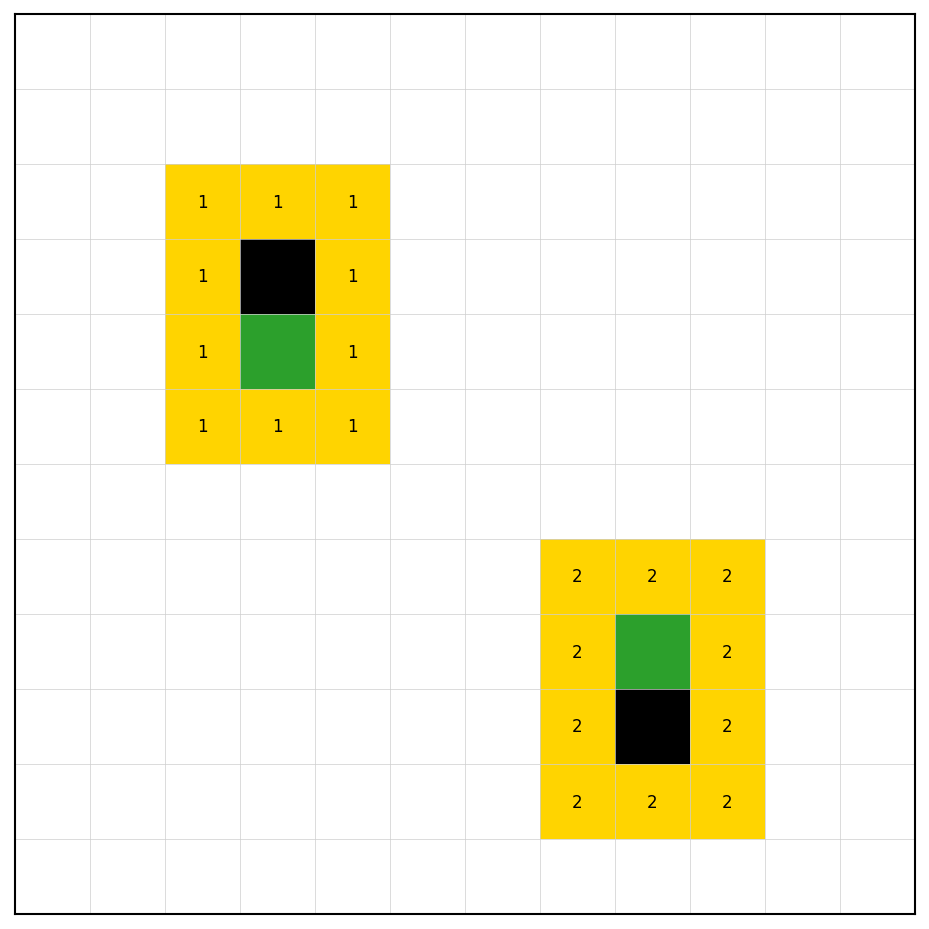

Case 2: Two Frontiers | detected frontier regions: 2
Case 2 frontier regions: 2


In [15]:
# Two-frontier mock grid

grid_two = np.full((12, 12), UNKNOWN, dtype=int)

# Left explored island
grid_two[2:6, 2:5] = FREE
# Right explored island
grid_two[7:11, 7:10] = FREE

# Obstacles on each island
grid_two[3, 3] = OCCUPIED
grid_two[9, 8] = OCCUPIED

n_two, frontier_two, labels_two = show_grid_with_frontiers(
    grid_two, "Case 2: Two Frontiers"
)
print(f"Case 2 frontier regions: {n_two}")